In [1]:
#importing libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
nltk.download('stopwords')
nltk.download('wordnet')

# Loading the dataset
df = pd.read_csv('/content/sentimentdataset.csv')

#printing the first 5 lines of the dataset
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
# Dropping unwanted columns
df.drop(columns='Unnamed: 0.1', inplace=True)
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)

In [3]:
df.head()

,Id,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [4]:
# Checking for missing values
df.isnull().sum()

# Displaying the column data types
df.dtypes

,0
Id,int64
Text,object
Sentiment,object
Timestamp,object
User,object
Platform,object
Hashtags,object
Retweets,float64
Likes,float64
Country,object


In [5]:
# Converting Timestamp to datetime format, for standardization of the dataset
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['Year'] = df['Timestamp'].dt.year

In [6]:
df.head()

,Id,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
# Drop the extra date and time columns
df.drop(columns=['Year', 'Month', 'Day','Hour'], inplace=True)
df.head()


,Id,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country
0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA
1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA
3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK
4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia


In [8]:
# Removing spaces from columns
df['Text'] = df['Text'].str.strip()
df['Sentiment'] = df['Sentiment'].str.strip()
df['User'] = df['User'].str.strip()
df['Platform'] = df['Platform'].str.strip()
df['Hashtags'] = df['Hashtags'].str.strip()
df['Country'] = df['Country'].str.strip()

In [9]:
df.head()

,Id,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country
0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA
1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA
3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK
4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia


In [10]:
# Statistics of the dataset
df.describe()

,Id,Timestamp,Retweets,Likes
count,732.000000,732,732.000000,732.000000
mean,369.740437,2020-12-08 21:37:38.196721408,21.508197,42.901639
min,0.000000,2010-05-15 15:30:00,5.000000,10.000000
25%,185.750000,2019-03-08 17:27:30,17.750000,34.750000
50%,370.500000,2021-09-20 14:30:00,22.000000,43.000000
75%,553.250000,2023-02-26 11:48:45,25.000000,50.000000
max,736.000000,2023-10-22 20:45:00,40.000000,80.000000
std,212.428936,NaN,7.061286,14.089848


In [11]:
print(df['Sentiment'].unique())


['Positive' 'Negative' 'Neutral' 'Anger' 'Fear' 'Sadness' 'Disgust'
 'Happiness' 'Joy' 'Love' 'Amusement' 'Enjoyment' 'Admiration' 'Affection'
 'Awe' 'Disappointed' 'Surprise' 'Acceptance' 'Adoration' 'Anticipation'
 'Bitter' 'Calmness' 'Confusion' 'Excitement' 'Kind' 'Pride' 'Shame'
 'Elation' 'Euphoria' 'Contentment' 'Serenity' 'Gratitude' 'Hope'
 'Empowerment' 'Compassion' 'Tenderness' 'Arousal' 'Enthusiasm'
 'Fulfillment' 'Reverence' 'Despair' 'Grief' 'Loneliness' 'Jealousy'
 'Resentment' 'Frustration' 'Boredom' 'Anxiety' 'Intimidation'
 'Helplessness' 'Envy' 'Regret' 'Curiosity' 'Indifference' 'Numbness'
 'Melancholy' 'Nostalgia' 'Ambivalence' 'Determination' 'Zest' 'Hopeful'
 'Proud' 'Grateful' 'Empathetic' 'Compassionate' 'Playful' 'Free-spirited'
 'Inspired' 'Confident' 'Bitterness' 'Yearning' 'Fearful' 'Apprehensive'
 'Overwhelmed' 'Jealous' 'Devastated' 'Frustrated' 'Envious' 'Dismissive'
 'Thrill' 'Bittersweet' 'Overjoyed' 'Inspiration' 'Motivation'
 'Contemplation' 'JoyfulR

In [12]:
# Original sentiment labels from the dataset
original_labels = ['Positive' 'Negative' 'Neutral' 'Anger' 'Fear' 'Sadness' 'Disgust'
 'Happiness' 'Joy' 'Love' 'Amusement' 'Enjoyment' 'Admiration' 'Affection'
 'Awe' 'Disappointed' 'Surprise' 'Acceptance' 'Adoration' 'Anticipation'
 'Bitter' 'Calmness' 'Confusion' 'Excitement' 'Kind' 'Pride' 'Shame'
 'Elation' 'Euphoria' 'Contentment' 'Serenity' 'Gratitude' 'Hope'
 'Empowerment' 'Compassion' 'Tenderness' 'Arousal' 'Enthusiasm'
 'Fulfillment' 'Reverence' 'Despair' 'Grief' 'Loneliness' 'Jealousy'
 'Resentment' 'Frustration' 'Boredom' 'Anxiety' 'Intimidation'
 'Helplessness' 'Envy' 'Regret' 'Curiosity' 'Indifference' 'Numbness'
 'Melancholy' 'Nostalgia' 'Ambivalence' 'Determination' 'Zest' 'Hopeful'
 'Proud' 'Grateful' 'Empathetic' 'Compassionate' 'Playful' 'Free-spirited'
 'Inspired' 'Confident' 'Bitterness' 'Yearning' 'Fearful' 'Apprehensive'
 'Overwhelmed' 'Jealous' 'Devastated' 'Frustrated' 'Envious' 'Dismissive'
 'Thrill' 'Bittersweet' 'Overjoyed' 'Inspiration' 'Motivation'
 'Contemplation' 'JoyfulReunion' 'Satisfaction' 'Blessed' 'Reflection'
 'Appreciation' 'Confidence' 'Accomplishment' 'Wonderment' 'Optimism'
 'Enchantment' 'Intrigue' 'PlayfulJoy' 'Mindfulness' 'DreamChaser'
 'Elegance' 'Whimsy' 'Pensive' 'Harmony' 'Creativity' 'Radiance' 'Wonder'
 'Rejuvenation' 'Coziness' 'Adventure' 'Melodic' 'FestiveJoy'
 'InnerJourney' 'Freedom' 'Dazzle' 'Adrenaline' 'ArtisticBurst'
 'CulinaryOdyssey' 'Resilience' 'Immersion' 'Spark' 'Marvel' 'Heartbreak'
 'Betrayal' 'Suffering' 'EmotionalStorm' 'Isolation' 'Disappointment'
 'LostLove' 'Exhaustion' 'Sorrow' 'Darkness' 'Desperation' 'Ruins'
 'Desolation' 'Loss' 'Heartache' 'Solitude' 'Positivity' 'Kindness'
 'Friendship' 'Success' 'Exploration' 'Amazement' 'Romance' 'Captivation'
 'Tranquility' 'Grandeur' 'Emotion' 'Energy' 'Celebration' 'Charm'
 'Ecstasy' 'Colorful' 'Hypnotic' 'Connection' 'Iconic' 'Journey'
 'Engagement' 'Touched' 'Suspense' 'Triumph' 'Heartwarming' 'Obstacle'
 'Sympathy' 'Pressure' 'Renewed Effort' 'Miscalculation' 'Challenge'
 'Solace' 'Breakthrough' 'Joy in Baking' 'Envisioning History'
 'Imagination' 'Vibrancy' 'Mesmerizing' 'Culinary Adventure'
 'Winter Magic' 'Thrilling Journey' "Nature's Beauty" 'Celestial Wonder'
 'Creative Inspiration' 'Runway Creativity' "Ocean's Freedom"
 'Whispers of the Past' 'Relief' 'Embarrassed' 'Mischievous' 'Sad' 'Hate'
 'Bad' 'Happy']

# Define mapping dictionaries
positive_words = {
    'positive', 'happiness', 'joy', 'love', 'amusement', 'enjoyment', 'admiration',
    'affection', 'awe', 'excitement', 'kind', 'pride', 'elation', 'euphoria',
    'contentment', 'serenity', 'gratitude', 'hope', 'empowerment', 'compassion',
    'tenderness', 'arousal', 'enthusiasm', 'fulfillment', 'reverence', 'hopeful',
    'proud', 'grateful', 'empathetic', 'compassionate', 'playful', 'free-spirited',
    'inspired', 'confident', 'thrill', 'bittersweet', 'overjoyed', 'inspiration',
    'motivation', 'joyfulreunion', 'satisfaction', 'blessed', 'appreciation',
    'confidence', 'accomplishment', 'wonderment', 'optimism', 'enchantment',
    'intrigue', 'playfuljoy', 'mindfulness', 'dreamchaser', 'elegance', 'whimsy',
    'harmony', 'creativity', 'radiance', 'wonder', 'rejuvenation', 'coziness',
    'adventure', 'melodic', 'festivejoy', 'innerjourney', 'freedom', 'dazzle',
    'artisticburst', 'culinaryodyssey', 'resilience', 'immersion', 'spark', 'marvel',
    'positivity', 'kindness', 'friendship', 'success', 'exploration', 'amazement',
    'romance', 'captivation', 'tranquility', 'grandeur', 'celebration', 'charm',
    'ecstasy', 'colorful', 'hypnotic', 'connection', 'iconic', 'journey', 'engagement',
    'touched', 'triumph', 'heartwarming', 'solace', 'breakthrough', 'joy in baking',
    'envisioning history', 'imagination', 'vibrancy', 'mesmerizing',
    'culinary adventure', 'winter magic', 'thrilling journey', "nature's beauty",
    'celestial wonder', 'creative inspiration', "ocean's freedom", 'whispers of the past',
    'relief', 'happy'
}

negative_words = {
    'negative', 'anger', 'fear', 'sadness', 'disgust', 'disappointed', 'bitter',
    'bitterness', 'jealousy', 'resentment', 'frustration', 'boredom', 'anxiety',
    'intimidation', 'helplessness', 'envy', 'regret', 'despair', 'grief', 'loneliness',
    'jealous', 'devastated', 'frustrated', 'envious', 'dismissive', 'heartbreak',
    'betrayal', 'suffering', 'emotionalstorm', 'isolation', 'disappointment',
    'lostlove', 'exhaustion', 'sorrow', 'darkness', 'desperation', 'ruins',
    'desolation', 'loss', 'heartache', 'solitude', 'obstacle', 'sympathy', 'pressure',
    'miscalculation', 'challenge', 'sad', 'hate', 'bad', 'embarrassed'
}

# Function to map each label
def map_to_sentiment(label):
    label = label.strip().lower()
    if label in positive_words:
        return 'positive'
    elif label in negative_words:
        return 'negative'
    else:
        return 'neutral'

# Apply this to the dataframe
df['Sentiment_Grouped'] = df['Sentiment'].apply(map_to_sentiment)


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Id                 732 non-null    int64         
 1   Text               732 non-null    object        
 2   Sentiment          732 non-null    object        
 3   Timestamp          732 non-null    datetime64[ns]
 4   User               732 non-null    object        
 5   Platform           732 non-null    object        
 6   Hashtags           732 non-null    object        
 7   Retweets           732 non-null    float64       
 8   Likes              732 non-null    float64       
 9   Country            732 non-null    object        
 10  Sentiment_Grouped  732 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 63.0+ KB


In [14]:
print(df['Sentiment_Grouped'].unique())


['positive' 'negative' 'neutral']


In [15]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Custom stopword list
basic_stopwords = set(["the", "a", "an", "is", "are", "in", "on", "and", "at", "to", "this", "that", "was", "for", "with", "by", "it"])

def clean_text(text):
    text = re.sub(r"http\S+|@\S+|#[^\s]+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower().strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in basic_stopwords]
    return " ".join(tokens)

df['Clean_Text'] = df['Text'].apply(clean_text)
df['Sentiment_Label'] = df['Sentiment_Grouped'].str.strip().astype('category').cat.codes

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Clean_Text'])
y = df['Sentiment_Label']


In [16]:
df['Clean_Text'].head()


,Clean_Text
0,enjoying beautiful day park
1,traffic terrible morning
2,just finished amazing workout
3,excited about upcoming weekend getaway
4,trying out new recipe dinner tonight


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
logreg_model = LogisticRegression(max_iter=1000)  # Increased max_iter
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.36      0.51        39
           1       1.00      0.36      0.53        25
           2       0.67      0.99      0.80        83

    accuracy                           0.71       147
   macro avg       0.85      0.57      0.61       147
weighted avg       0.78      0.71      0.68       147



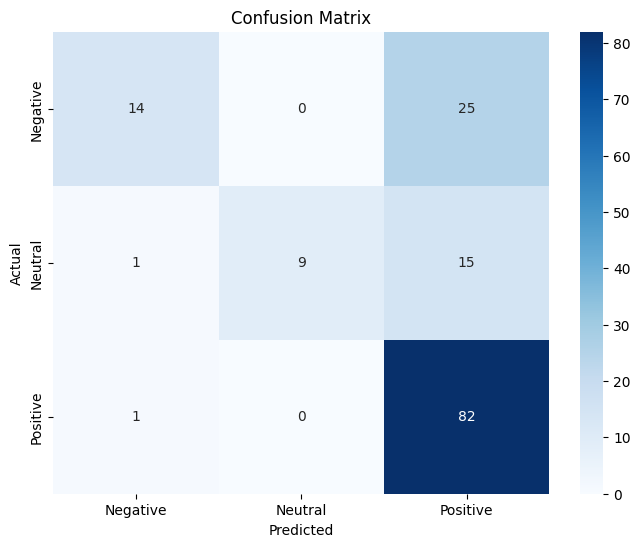

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Initialize and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.95      0.51      0.67        39
           1       0.82      0.36      0.50        25
           2       0.71      0.99      0.83        83

    accuracy                           0.76       147
   macro avg       0.83      0.62      0.66       147
weighted avg       0.79      0.76      0.73       147



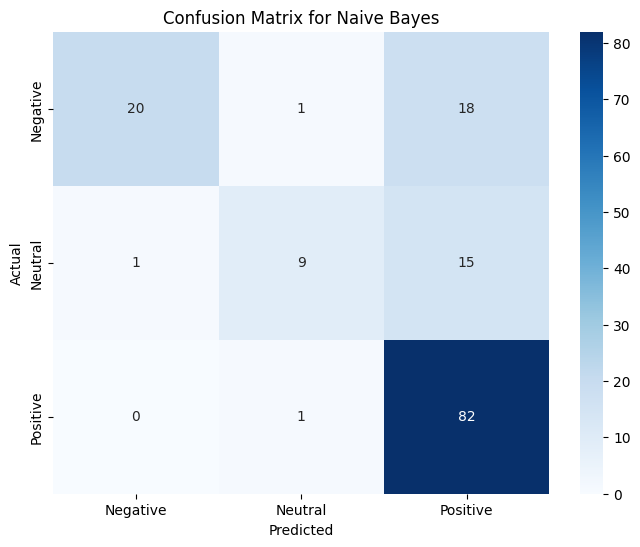

In [20]:
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Naive Bayes")
plt.show()


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.56      0.70        39
           1       1.00      0.44      0.61        25
           2       0.73      0.99      0.84        83

    accuracy                           0.78       147
   macro avg       0.88      0.66      0.72       147
weighted avg       0.83      0.78      0.76       147



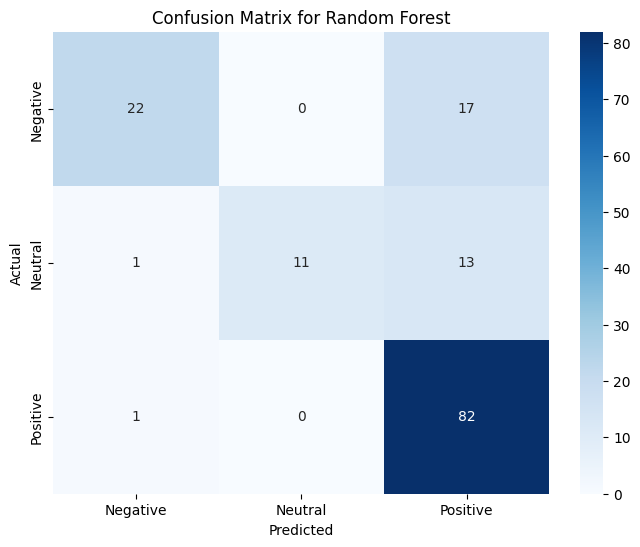

In [22]:
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Forest")
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Support Vector Machine model
svm_model = SVC(kernel='linear', random_state=42) # You can experiment with different kernels
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.87      0.69      0.77        39
           1       0.93      0.52      0.67        25
           2       0.79      0.98      0.88        83

    accuracy                           0.82       147
   macro avg       0.86      0.73      0.77       147
weighted avg       0.84      0.82      0.81       147



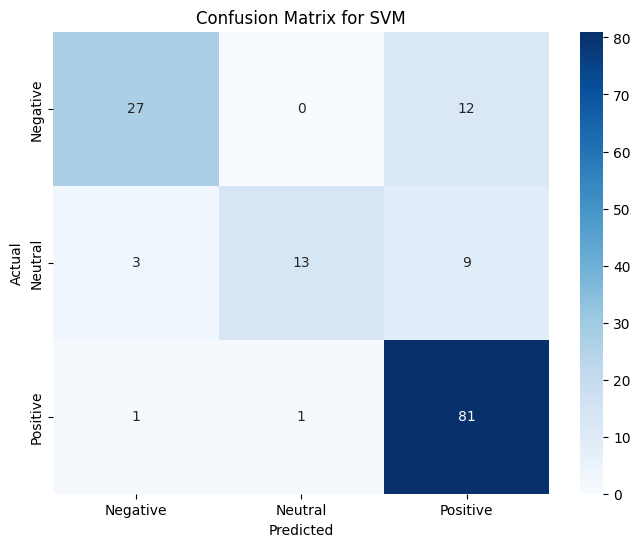

In [24]:
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()


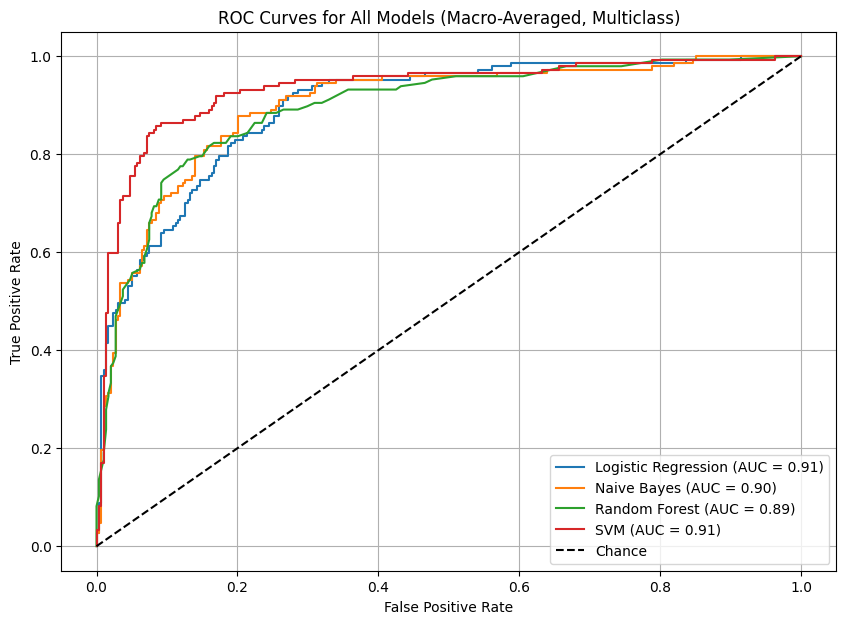

Model Accuracy Comparison:
Logistic Regression: 0.7142857142857143
Naive Bayes: 0.7551020408163265
Random Forest: 0.7619047619047619
SVM: 0.8231292517006803


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Define and train models
logreg_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()
rf_model = RandomForestClassifier(n_estimators=100)
svm_model = SVC(probability=True, kernel='linear')

logreg_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# 2. Predict probabilities
y_pred_prob_logreg = logreg_model.predict_proba(X_test)
y_pred_prob_nb = nb_model.predict_proba(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)
y_pred_prob_svm = svm_model.predict_proba(X_test)

# 3. Binarize y_test for ROC
num_classes = len(set(y_train))
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

# 4. Calculate AUC for each model (macro average)
auc_logreg = roc_auc_score(y_test_bin, y_pred_prob_logreg, average="macro", multi_class="ovr")
auc_nb = roc_auc_score(y_test_bin, y_pred_prob_nb, average="macro", multi_class="ovr")
auc_rf = roc_auc_score(y_test_bin, y_pred_prob_rf, average="macro", multi_class="ovr")
auc_svm = roc_auc_score(y_test_bin, y_pred_prob_svm, average="macro", multi_class="ovr")

# 5. Plot macro-averaged ROC curves for comparison
fpr_logreg, tpr_logreg, _ = roc_curve(y_test_bin.ravel(), y_pred_prob_logreg.ravel())
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin.ravel(), y_pred_prob_nb.ravel())
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_pred_prob_rf.ravel())
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_pred_prob_svm.ravel())

plt.figure(figsize=(10, 7))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.title("ROC Curves for All Models (Macro-Averaged, Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# 6. Accuracy scores for comparison
y_pred_logreg = logreg_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

print("Model Accuracy Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_logreg))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))


Hypothesis-**Does sentiments differ by platforms**

*   Null Hypothesis: Sentiment distribution does not vary significantly across platforms.
*   Alternate Hypothesis: ASentiment distribution varies across platforms.

In [26]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['Platform'], df['Sentiment_Grouped'])

# Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

# Determine which hypothesis is supported
alpha = 0.05  # Significance level
if p < alpha:
    print("H1 is true: Sentiment distribution differs by platform.")
else:
    print("H0 is true: Sentiment distribution does not differ by platform.")


Chi-squared statistic: 0.7118671714377808
P-value: 0.9498574336573091
H0 is true: Sentiment distribution does not differ by platform.


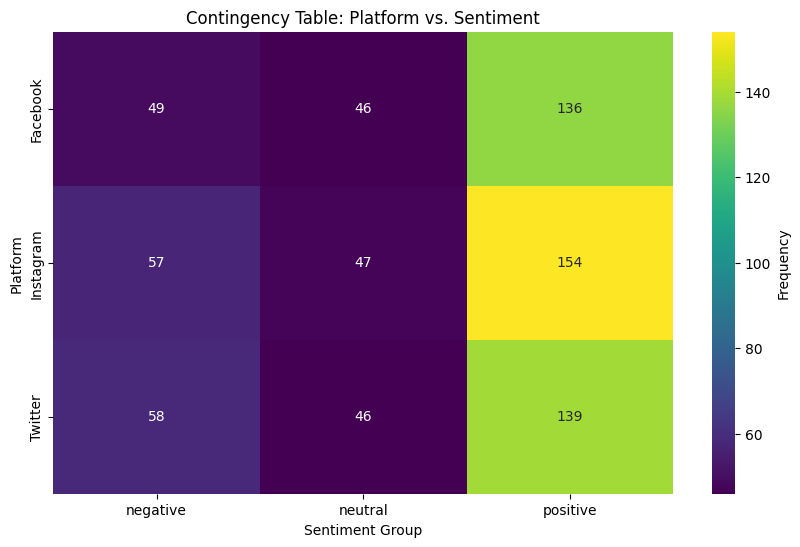

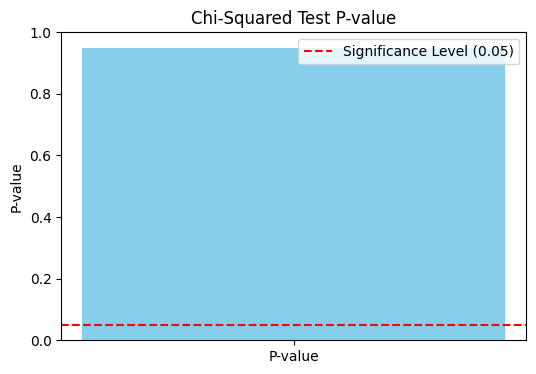

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import pandas as pd

# Visualize the contingency table as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="viridis", cbar_kws={'label': 'Frequency'})
plt.title("Contingency Table: Platform vs. Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Platform")
plt.show()

# Visualizing the p-value
plt.figure(figsize=(6, 4))
plt.bar(['P-value'], [p], color=['skyblue'])
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
plt.ylabel("P-value")
plt.title("Chi-Squared Test P-value")
plt.ylim(0, 1)
plt.legend()
plt.show()


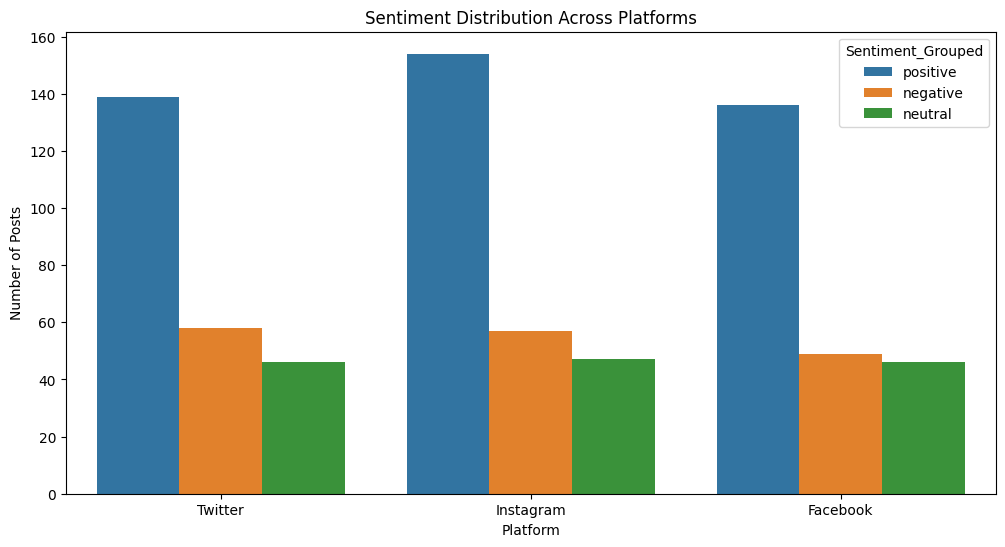

ANOVA F-statistic: 0.02111944604731679
ANOVA P-value: 0.9791744555731762
Fail to reject the null hypothesis. Sentiment distribution does not vary significantly across platforms.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(x='Platform', hue='Sentiment_Grouped', data=df)
plt.title('Sentiment Distribution Across Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.show()

# Perform ANOVA test
platforms = df['Platform'].unique()
sentiment_groups = df['Sentiment_Grouped'].unique()

anova_data = {}
for platform in platforms:
    anova_data[platform] = []
    for sentiment in sentiment_groups:
      anova_data[platform].append(len(df[(df['Platform'] == platform) & (df['Sentiment_Grouped'] == sentiment)]))


f_statistic, p_value = f_oneway(*anova_data.values())


# Print ANOVA results
print(f"ANOVA F-statistic: {f_statistic}")
print(f"ANOVA P-value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. Sentiment distribution varies across platforms.")
else:
    print("Fail to reject the null hypothesis. Sentiment distribution does not vary significantly across platforms.")


Hypothesis-**Do positive posts get more likes**

*   Null Hypothesis: Likes differ significantly by sentiment.Positive posts get more likes than others.
*   Alternate Hypothesis: Likes do not differ significantly by sentiment.

Reject the null hypothesis. At least one sentiment group has a different average number of likes.

Hypothesis 2: Likes differ by Sentiment
ANOVA p-value: 1.2213705078053843e-17


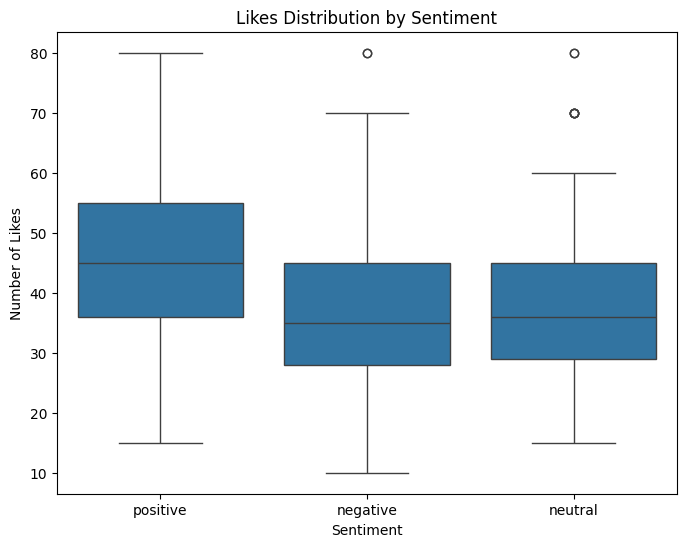

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# H2: Do positive posts get more likes than others?
positive_likes = df[df['Sentiment_Grouped'] == 'positive']['Likes']
neutral_likes = df[df['Sentiment_Grouped'] == 'neutral']['Likes']
negative_likes = df[df['Sentiment_Grouped'] == 'negative']['Likes']

f_stat, p_value = f_oneway(positive_likes, neutral_likes, negative_likes)
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. At least one sentiment group has a different average number of likes.")
else:
    print("Fail to reject the null hypothesis. Yes, the average number of likes is the same across sentiment groups (positive, neutral, negative)")

print("\nHypothesis 2: Likes differ by Sentiment")
print("ANOVA p-value:", p_value)

# Visualization (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment_Grouped', y='Likes', data=df)
plt.title('Likes Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Likes')
plt.show()


Hypothesis-**Is there a significant difference in likes/retweets across platforms?**

*   Null Hypothesis: Mean engagement is the same on all platforms.
*   Alternate Hypothesis: At least one platform differs in terms of mean user engegement.

T-test results for Likes: Facebook vs Instagram
T-statistic: -2.47173113257322
P-value: 0.013786905956680346

T-test results for Retweets: Facebook vs Instagram
T-statistic: -2.497552165754012
P-value: 0.012834338215203763
--------------------
T-test results for Likes: Facebook vs Twitter
T-statistic: 0.25950128521801297
P-value: 0.7953616358342335

T-test results for Retweets: Facebook vs Twitter
T-statistic: 0.18273917312057006
P-value: 0.8550811407695639
--------------------
T-test results for Likes: Instagram vs Twitter
T-statistic: 2.7123751548727704
P-value: 0.006910955227809179

T-test results for Retweets: Instagram vs Twitter
T-statistic: 2.6711812418382768
P-value: 0.007805390862656868
--------------------


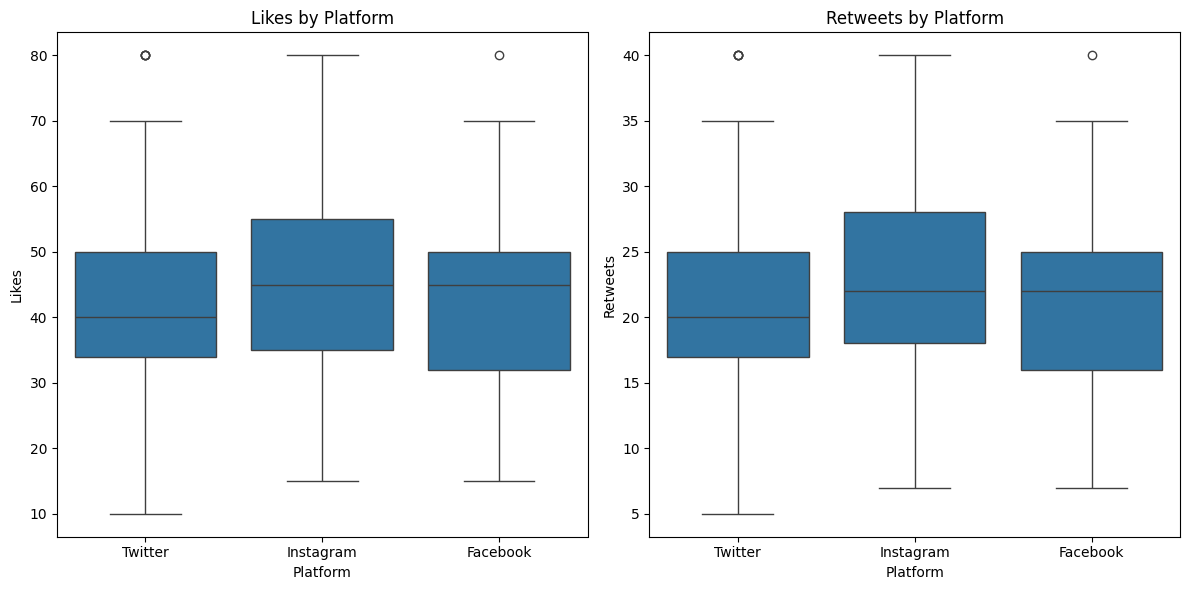

In [30]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Group data by platform
platform_groups = df.groupby('Platform')

# Perform t-tests for likes and retweets across platforms
platforms = list(platform_groups.groups.keys())
for i in range(len(platforms)):
    for j in range(i + 1, len(platforms)):
        platform1 = platforms[i]
        platform2 = platforms[j]

        t_stat_likes, p_value_likes = ttest_ind(platform_groups.get_group(platform1)['Likes'], platform_groups.get_group(platform2)['Likes'])
        t_stat_retweets, p_value_retweets = ttest_ind(platform_groups.get_group(platform1)['Retweets'], platform_groups.get_group(platform2)['Retweets'])

        print(f"T-test results for Likes: {platform1} vs {platform2}")
        print(f"T-statistic: {t_stat_likes}")
        print(f"P-value: {p_value_likes}")

        print(f"\nT-test results for Retweets: {platform1} vs {platform2}")
        print(f"T-statistic: {t_stat_retweets}")
        print(f"P-value: {p_value_retweets}")
        print("-" * 20)


# Box plots for likes and retweets by platform
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Platform', y='Likes', data=df)
plt.title('Likes by Platform')

plt.subplot(1, 2, 2)
sns.boxplot(x='Platform', y='Retweets', data=df)
plt.title('Retweets by Platform')

plt.tight_layout()
plt.show()


Hypothesis-**Is there a linear relationship between number of likes and retweets?**

*   Null Hypothesis: No correlation between likes and retweets.
*   Alternate Hypothesis: Significant correlation exists.

Pearson correlation coefficient: 0.9984821119176872
P-value: 0.0
Slope: 0.500400570423126
Intercept: 0.0401919213553974
R-value: 0.9984821119176841
P-value: 0.0
Standard error: 0.0010216122350126418


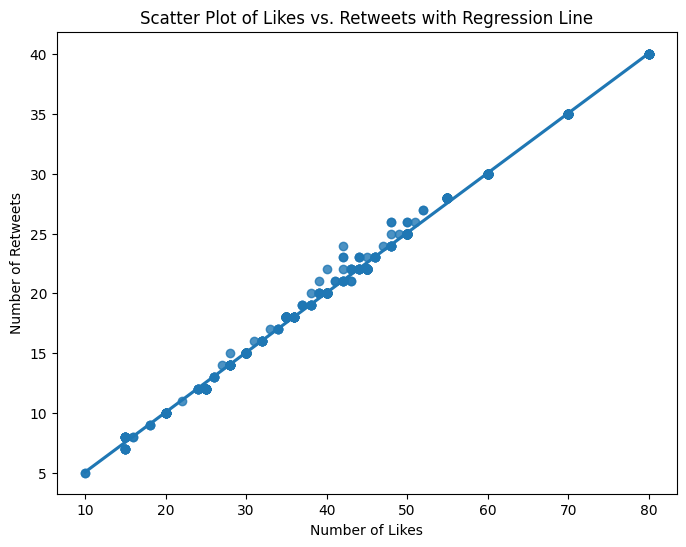

Reject the null hypothesis. There is a statistically significant correlation between likes and retweets.


In [31]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(df['Likes'], df['Retweets'])

print(f"Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(df['Likes'], df['Retweets'])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-value: {r_value}")  # R-value (correlation coefficient)
print(f"P-value: {p_value}")
print(f"Standard error: {std_err}")

# Create the scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='Likes', y='Retweets', data=df)
plt.title('Scatter Plot of Likes vs. Retweets with Regression Line')
plt.xlabel('Number of Likes')
plt.ylabel('Number of Retweets')
plt.show()

# Interpretation based on p-value
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant correlation between likes and retweets.")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant correlation between likes and retweets.")


 Hypothesis-**Is there a linear relationship between Likes and Sentiments**

*   Null Hypothesis: There is no linear correlation between sentiment and likes.
*   Alternate Hypothesis: There is a significant linear correlation between sentiment and likes.



Reject the null hypothesis. There is a significant linear correlation between sentiment and likes.
ANOVA p-value: 1.2213705078053843e-17
Correlation between Likes and Sentiment: 0.30189635759892924


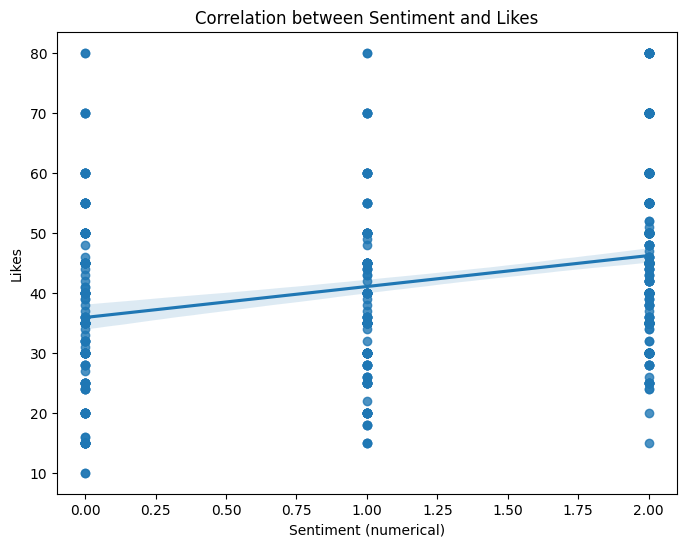

In [32]:
# Convert sentiment to numerical representation (0 for Negative, 1 for Neutral, 2 for Positive)
sentiment_mapping = {'negative':0, 'neutral':1, 'positive':2}
df['Sentiment_numeric'] = df['Sentiment_Grouped'].map(sentiment_mapping)
f_stat, p_value = f_oneway(positive_likes, neutral_likes, negative_likes)
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant linear correlation between sentiment and likes.")
else:
    print("Fail to reject the null hypothesis. There is no linear correlation between sentiment and likes.")

print("ANOVA p-value:", p_value)
# Calculate correlation
correlation = df['Likes'].corr(df['Sentiment_numeric'], method='pearson')
print("Correlation between Likes and Sentiment:", correlation)

plt.figure(figsize=(8,6))
sns.regplot(x="Sentiment_numeric", y="Likes", data=df)
plt.xlabel("Sentiment (numerical)")
plt.ylabel("Likes")
plt.title("Correlation between Sentiment and Likes")
plt.show()

 Hypothesis-**Does sentiment trend change over time**

*   Null Hypothesis:The average sentiment scores are the same across all years.
*   Alternate Hypothesis: At least one year has a different average sentiment score.



Reject the null hypothesis. At least one year has a different average sentiment score.
ANOVA p-value: 1.2213705078053843e-17
              sum_sq     df         F   PR(>F)
C(Year)    14.989815   13.0  1.717368  0.05303
Residual  482.074392  718.0       NaN      NaN


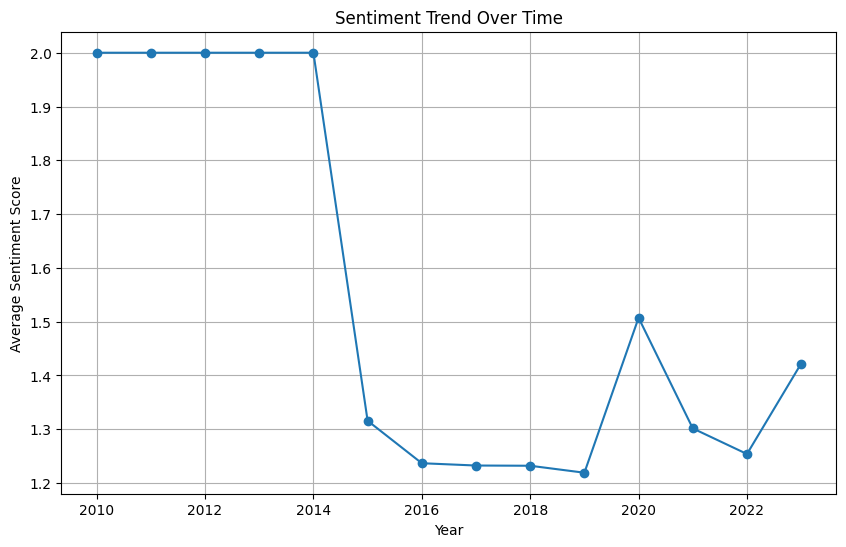

In [33]:
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

df['Year'] = df['Timestamp'].dt.year

# Group data by year and calculate the mean sentiment score for each year
yearly_sentiment = df.groupby('Year')['Sentiment_numeric'].mean()

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. At least one year has a different average sentiment score.")
else:
    print("Fail to reject the null hypothesis. The average sentiment scores are the same across all years.")

print("ANOVA p-value:", p_value)

# Perform ANOVA test
model = ols('Sentiment_numeric ~ C(Year)', data=df).fit()
anova_table = anova_lm(model, typ=2)

print(anova_table)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_sentiment.index, yearly_sentiment.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Trend Over Time')
plt.grid(True)
plt.show()


In [34]:

final_model = SVC(kernel='linear', random_state=42)
final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))


Final Model Accuracy: 0.8231292517006803
              precision    recall  f1-score   support

           0       0.87      0.69      0.77        39
           1       0.93      0.52      0.67        25
           2       0.79      0.98      0.88        83

    accuracy                           0.82       147
   macro avg       0.86      0.73      0.77       147
weighted avg       0.84      0.82      0.81       147



In [35]:
import pandas as pd
from collections import Counter

def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

from sklearn.feature_extraction.text import CountVectorizer

top_words = get_top_n_words(df['Clean_Text'], n=10)
top_df = pd.DataFrame(top_words)
top_df.columns=["Word", "Freq"]

top_df


,Word,Freq
0,of,623
1,through,52
2,new,43
3,my,41
4,as,41
5,each,39
6,like,27
7,day,26
8,feeling,26
9,after,25


**Platform-Specific Analysis:**

*   Compare sentiment trends across various platforms using the "Platform" column.

*   Identify how emotions differ depending on the platform.





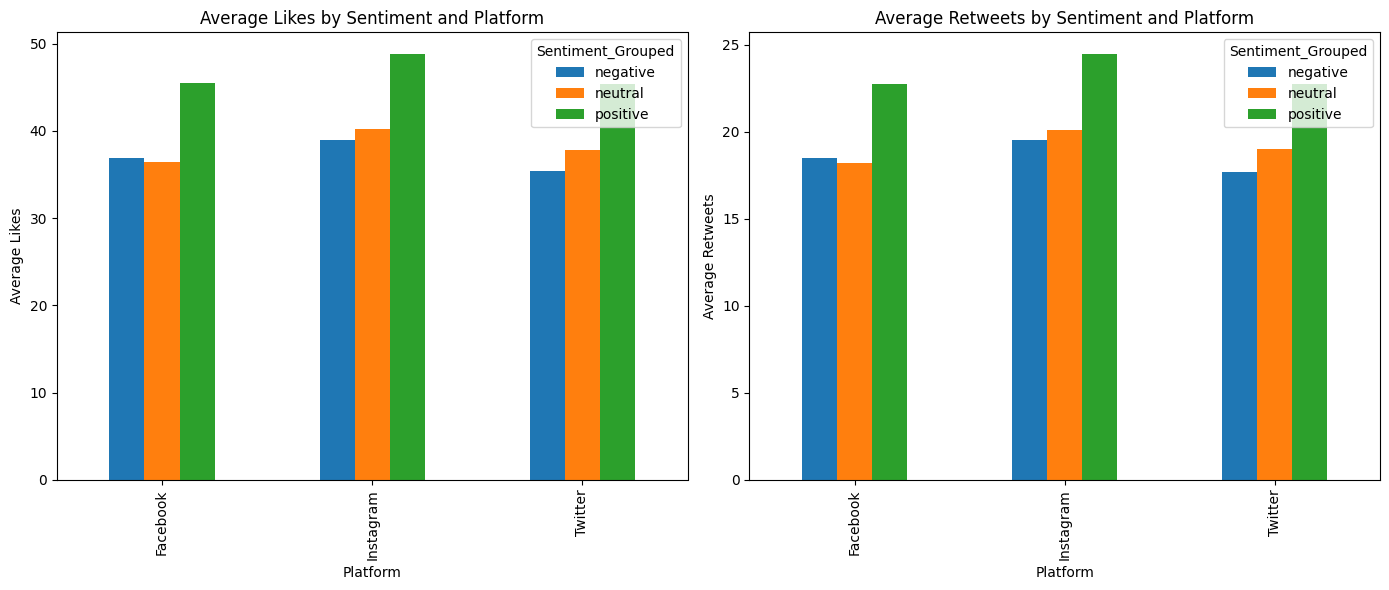

In [36]:
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind, pearsonr
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import linregress
from sklearn.feature_extraction.text import CountVectorizer
# Group data by platform and sentiment, then calculate the mean of 'Likes' and 'Retweets' for each group
platform_sentiment_means = df.groupby(['Platform', 'Sentiment_Grouped'])[['Likes', 'Retweets']].mean().reset_index()

# Pivot the table to have platforms as rows and sentiment as columns
pivot_likes = platform_sentiment_means.pivot(index='Platform', columns='Sentiment_Grouped', values='Likes')
pivot_retweets = platform_sentiment_means.pivot(index='Platform', columns='Sentiment_Grouped', values='Retweets')


# Plotting Sentiment Trends across Platforms
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
pivot_likes.plot(kind='bar', ax=plt.gca())  # Use the current axes
plt.title('Average Likes by Sentiment and Platform')
plt.ylabel('Average Likes')

plt.subplot(1, 2, 2)
pivot_retweets.plot(kind='bar', ax=plt.gca())
plt.title('Average Retweets by Sentiment and Platform')
plt.ylabel('Average Retweets')

plt.tight_layout()
plt.show()


**Hashtag and Topic Trends:**

*   Explore trending topics by analyzing the hashtags.
*   Investigate the relationship between hashtags and user engagement or sentiment.





In [37]:
from collections import Counter

def analyze_hashtags(df):
    # 1. Top 10 hashtags by frequency
    all_hashtags = []
    for hashtags in df['Hashtags'].dropna():  # Drop rows with missing hashtags
        if isinstance(hashtags, str) and len(hashtags) > 0:  # Check for empty strings or non-string values
          all_hashtags.extend(hashtags.split(','))

    hashtag_counts = Counter(all_hashtags)
    top_10_hashtags = hashtag_counts.most_common(10)
    print("Top 10 Hashtags by Frequency:")
    for tag, count in top_10_hashtags:
      print(f"{tag}: {count}")

    #2. Top 10 most liked hashtags
    hashtag_likes = {}
    for index, row in df.dropna(subset=['Hashtags','Likes']).iterrows():
        hashtags_list = row['Hashtags'].split(',')
        likes = row['Likes']
        for hashtag in hashtags_list:
            hashtag_likes[hashtag] = hashtag_likes.get(hashtag, 0) + likes

    sorted_hashtag_likes = dict(sorted(hashtag_likes.items(), key=lambda item: item[1], reverse=True))
    top_10_liked_hashtags = list(sorted_hashtag_likes.keys())[:10]
    print("\nTop 10 Most Liked Hashtags:")
    for tag in top_10_liked_hashtags:
      print(f"{tag}: {hashtag_likes[tag]}")


    # 3. Top 10 most retweeted hashtags
    hashtag_retweets = {}
    for index, row in df.dropna(subset=['Hashtags','Retweets']).iterrows():
        hashtags_list = row['Hashtags'].split(',')
        retweets = row['Retweets']
        for hashtag in hashtags_list:
            hashtag_retweets[hashtag] = hashtag_retweets.get(hashtag, 0) + retweets

    sorted_hashtag_retweets = dict(sorted(hashtag_retweets.items(), key=lambda item: item[1], reverse=True))

    top_10_retweeted_hashtags = list(sorted_hashtag_retweets.keys())[:10]
    print("\nTop 10 Most Retweeted Hashtags:")
    for tag in top_10_retweeted_hashtags:
      print(f"{tag}: {hashtag_retweets[tag]}")

analyze_hashtags(df)


Top 10 Hashtags by Frequency:
#Compassionate #TearsOfEmpathy: 3
#Proud #ScalingPeaks: 3
#Hopeful #SeedsOfOptimism: 3
#Playful #CarnivalEscapade: 3
#Love #SpreadLove: 2
#Shame #Injustice: 2
#Disgust #Corruption: 2
#Acceptance #LifeJourney: 2
#Frustration #EmotionalOutburst: 2
#Numbness #EmotionalShield: 2

Top 10 Most Liked Hashtags:
#Wonder #StargazingAdventure: 160.0
#Playful #CarnivalEscapade: 144.0
#Harmony #MusicalUnity: 140.0
#Proud #ScalingPeaks: 138.0
#Compassionate #TearsOfEmpathy: 126.0
#Coziness #WarmWinterEvening: 120.0
#Inspiration #ForestWhispers: 110.0
#Playful #JugglingResponsibilities: 100.0
#Radiance #SpringBlooms: 100.0
#TimelessTunes #SeniorJazz: 100.0

Top 10 Most Retweeted Hashtags:
#Wonder #StargazingAdventure: 80.0
#Playful #CarnivalEscapade: 72.0
#Harmony #MusicalUnity: 70.0
#Proud #ScalingPeaks: 69.0
#Compassionate #TearsOfEmpathy: 63.0
#Coziness #WarmWinterEvening: 60.0
#Inspiration #ForestWhispers: 56.0
#Playful #JugglingResponsibilities: 50.0
#Radiance #Spri

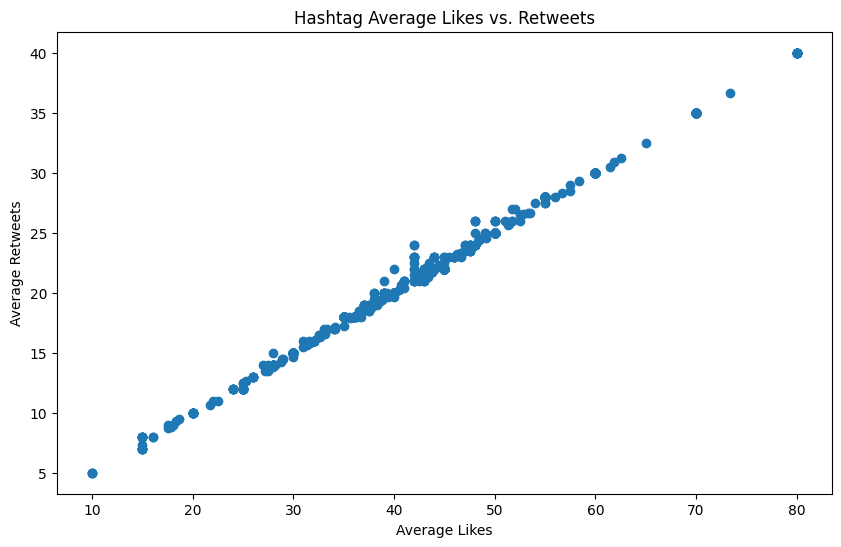

In [38]:
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def extract_hashtags(text):
    # Check if text is a string, if not, convert it to a string
    if not isinstance(text, str):
        text = str(text)
    # Use a regular expression to find all hashtags
    hashtags = re.findall(r"#(\w+)", text)
    return hashtags

# Apply the function to extract hashtags from each tweet
df['Extracted_Hashtags'] = df['Hashtags'].apply(extract_hashtags)

# Flatten the list of hashtags
all_hashtags = [hashtag for sublist in df['Extracted_Hashtags'] for hashtag in sublist]

# Relationship between hashtags, likes, retweets, and sentiment
hashtag_engagement = {}
for index, row in df.iterrows():
    for hashtag in row['Extracted_Hashtags']:
        if hashtag not in hashtag_engagement:
            hashtag_engagement[hashtag] = {'likes': [], 'retweets': [], 'sentiment': []}
        hashtag_engagement[hashtag]['likes'].append(row['Likes'])
        hashtag_engagement[hashtag]['retweets'].append(row['Retweets'])
        hashtag_engagement[hashtag]['sentiment'].append(row['Sentiment_Grouped']) # Assuming you have a Sentiment_Grouped column

# Plot average engagement for each hashtag
avg_engagement = {}
for hashtag, data in hashtag_engagement.items():
    avg_engagement[hashtag] = {
        'avg_likes': np.mean(data['likes']),
        'avg_retweets': np.mean(data['retweets'])
    }

# Extract data for plotting
x_values = [data['avg_likes'] for data in avg_engagement.values()]  # Extract avg_likes
y_values = [data['avg_retweets'] for data in avg_engagement.values()]  # Extract avg_retweets

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values)  # Use extracted data for plotting
plt.xlabel("Average Likes")
plt.ylabel("Average Retweets")
plt.title("Hashtag Average Likes vs. Retweets")
plt.show()

**Geographical Trends:**

*   Examine regional sentiment variations using the "Country" column.
*   Understand how social media content and sentiment differ across various regions.

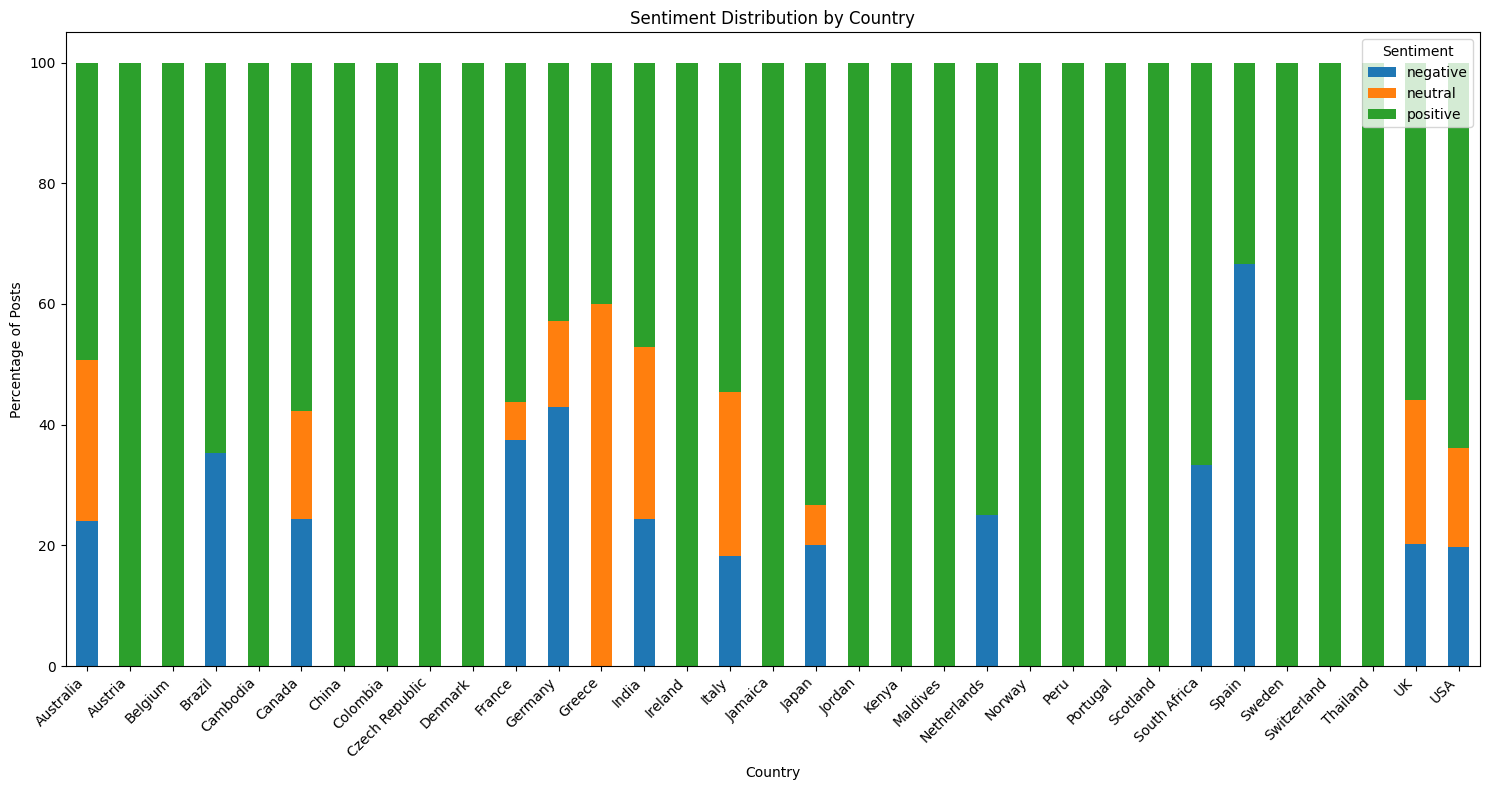

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by country and sentiment, then count the occurrences
country_sentiment_counts = df.groupby(['Country', 'Sentiment_Grouped']).size().unstack(fill_value=0)

# Normalize the counts to percentages for better comparison
country_sentiment_percentages = country_sentiment_counts.div(country_sentiment_counts.sum(axis=1), axis=0) * 100

# Plotting the sentiment distribution for each country
country_sentiment_percentages.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Sentiment Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Percentage of Posts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


**Cross-Feature Analysis:**


*   Combine features (e.g., sentiment and hashtags, sentiment and platform) to uncover deeper insights about user behavior and content trends.
*   We have combines sentiments and hastags.



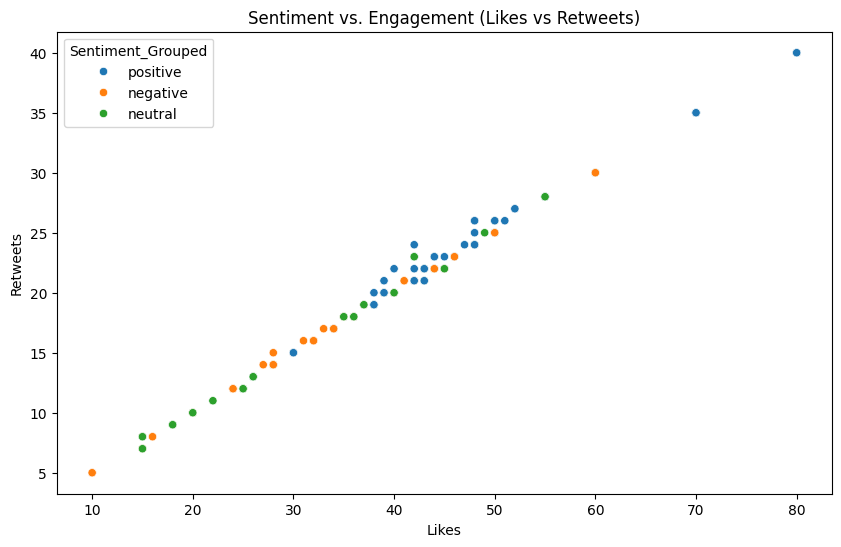

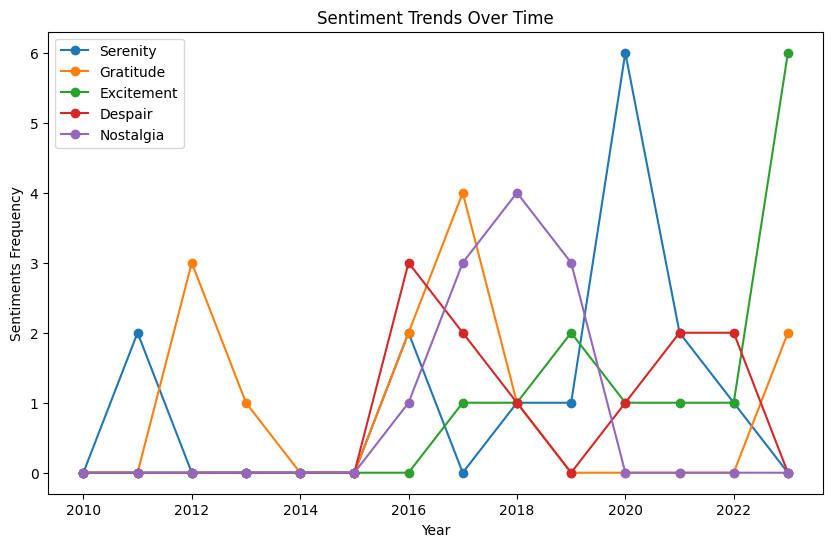

In [42]:
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind, pearsonr
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import linregress
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

#Scatter plot of likes vs retweets colored by sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Likes', y='Retweets', hue='Sentiment_Grouped')
plt.title('Sentiment vs. Engagement (Likes vs Retweets)')
plt.xlabel('Likes')
plt.ylabel('Retweets')
plt.show()

# Plotting hashtag frequency over time
# Group by year and count the frequency of each hashtag
# 1. Explode the 'Extracted_Hashtags' column to have one row per hashtag:
hashtag_df = df.explode('Extracted_Hashtags', ignore_index=True)
# 2. Now you can group by year and hashtag:
hashtag_year_counts = hashtag_df.groupby(['Year', 'Extracted_Hashtags']).size().unstack(fill_value=0)

# Calculate hashtag_counts here
all_hashtags = [hashtag for sublist in df['Extracted_Hashtags'] for hashtag in sublist]
hashtag_counts = Counter(all_hashtags)

# Plot the frequency of top hashtags over time
top_hashtags = hashtag_counts.most_common(5)  # Get top 5 hashtags
plt.figure(figsize=(10, 6))
for hashtag, _ in top_hashtags:
    if hashtag in hashtag_year_counts.columns:
      plt.plot(hashtag_year_counts.index, hashtag_year_counts[hashtag], label=hashtag, marker='o')
plt.xlabel('Year')
plt.ylabel('Sentiments Frequency')
plt.title('Sentiment Trends Over Time')
plt.legend()
plt.show()